In [1]:
from dotenv import load_dotenv
import praw
import os

load_dotenv()

reddit = praw.Reddit(
    client_id=os.getenv("CLIENT_ID"),
    client_secret=os.getenv("CLIENT_SECRET"),
    password=os.getenv("PASSWORD"),
    user_agent=os.getenv("USER_AGENT"),
    username=os.getenv("USERNAME")
)

In [2]:
# get the top subreddits
fetched_subs = list(reddit.subreddits.popular(limit=1000))

In [3]:
top_by_subscribers = sorted(fetched_subs, key=lambda sub: sub.subscribers, reverse=True)

In [4]:
for i, subreddit in enumerate(top_by_subscribers[200:300], start=1):
    print(f"{i}. /r/{subreddit.display_name} - {subreddit.subscribers:,} subscribers")

1. /r/MurderedByWords - 3,276,254 subscribers
2. /r/cursedcomments - 3,268,807 subscribers
3. /r/Marvel - 3,262,990 subscribers
4. /r/zelda - 3,255,996 subscribers
5. /r/languagelearning - 3,235,871 subscribers
6. /r/GirlsFinishingTheJob - 3,228,082 subscribers
7. /r/horror - 3,205,488 subscribers
8. /r/AsiansGoneWild - 3,193,566 subscribers
9. /r/frugalmalefashion - 3,172,089 subscribers
10. /r/writing - 3,169,026 subscribers
11. /r/teenagers - 3,153,960 subscribers
12. /r/youtube - 3,145,137 subscribers
13. /r/de - 3,136,257 subscribers
14. /r/techsupport - 3,135,314 subscribers
15. /r/WhitePeopleTwitter - 3,125,101 subscribers
16. /r/NSFW_GIF - 3,123,563 subscribers
17. /r/BaldursGate3 - 3,115,919 subscribers
18. /r/3Dprinting - 3,106,271 subscribers
19. /r/comics - 3,089,212 subscribers
20. /r/Android - 3,078,080 subscribers
21. /r/Naruto - 3,074,687 subscribers
22. /r/popheads - 3,055,890 subscribers
23. /r/Watches - 3,051,875 subscribers
24. /r/legaladvice - 3,048,772 subscribers

In [5]:
for submission in subreddit.hot(limit=10):
    print(submission.title)
    print(submission.score)
    print("-" * 30)

OUR RULES ON POLITICS:2025
785
------------------------------
Was I lucky?
2769
------------------------------
Completed my first solo!
1189
------------------------------
F/A-18E and tow tractor lost at sea during operations aboard USS Truman
790
------------------------------
It’s fun how close you are to the engine on the 717
346
------------------------------
RAH-66 Comanche at Army Aviation Museum
280
------------------------------
I took this exactly 5 years ago today. Crazy to look back and see it.
961
------------------------------
My dad's had this forever and is 99% sure it's a plane part, anyone recognize it?
320
------------------------------
Saw another plane nearly parallel with ours
198
------------------------------
India signs $7.4 billion deal to buy 26 Rafale fighter jets
388
------------------------------


In [33]:
def get_subreddits(start_subreddit = 200, n_subreddits = 10):
    fetched_subs = list(reddit.subreddits.popular(limit=1000))
    top_by_subscribers = sorted(fetched_subs, key=lambda sub: sub.subscribers, reverse=True)
    subreddits = []
    for i, subreddit in enumerate(top_by_subscribers[start_subreddit:start_subreddit+n_subreddits], start=start_subreddit):
        print(f"{i}. /r/{subreddit.display_name} - {subreddit.subscribers:,} subscribers")
        subreddits.append(subreddit)
    return subreddits

subreddits = get_subreddits()

200. /r/MurderedByWords - 3,276,240 subscribers
201. /r/cursedcomments - 3,268,789 subscribers
202. /r/Marvel - 3,262,990 subscribers
203. /r/zelda - 3,255,963 subscribers
204. /r/languagelearning - 3,235,836 subscribers
205. /r/GirlsFinishingTheJob - 3,228,055 subscribers
206. /r/horror - 3,205,486 subscribers
207. /r/AsiansGoneWild - 3,193,538 subscribers
208. /r/frugalmalefashion - 3,172,074 subscribers
209. /r/writing - 3,169,008 subscribers


In [34]:
subreddits

[Subreddit(display_name='MurderedByWords'),
 Subreddit(display_name='cursedcomments'),
 Subreddit(display_name='Marvel'),
 Subreddit(display_name='zelda'),
 Subreddit(display_name='languagelearning'),
 Subreddit(display_name='GirlsFinishingTheJob'),
 Subreddit(display_name='horror'),
 Subreddit(display_name='AsiansGoneWild'),
 Subreddit(display_name='frugalmalefashion'),
 Subreddit(display_name='writing')]

In [40]:
from collections import defaultdict

MAX_COMMENT_LEN = 250

def get_top_bot_comments(dict_comments, subreddit_obj, n_submissions=2, n_comments=2):
    sub_name = subreddit_obj.display_name  # use name as the key

    if sub_name not in dict_comments:
        dict_comments[sub_name] = {}

    for submission in subreddit_obj.top(limit=n_submissions, time_filter='month'):
        submission.comments.replace_more(limit=None)
        comments = [c for c in submission.comments.list() if hasattr(c, "score")]

        sorted_comments = sorted(comments, key=lambda com: com.score, reverse=True)
        top_comments = sorted_comments[:n_comments]
        bottom_comments = sorted_comments[-n_comments:]

        dict_comments[sub_name][submission.title] = []  # or submission.id if title is too long

        for comment in top_comments + bottom_comments:
            comment_summary = {
                "score": comment.score,
                "body": comment.body[:MAX_COMMENT_LEN]
            }
            dict_comments[sub_name][submission.title].append(comment_summary)

            # Print to console
            print(f"Score: {comment.score}")
            print(comment.body[:MAX_COMMENT_LEN])
            print("-" * 30)

    return dict_comments

dict_comments = {}
dict_comments = get_top_bot_comments(dict_comments, subreddits[0])

Score: 5929
When trump got covid they used a regimen that included medicine made from stem cells only obtained to from aborted fetuses 
------------------------------
Score: 2265
While he told the peasants to huff lysol
------------------------------
Score: -37
What's disturbing is the Adenovirus pill that the military makes people swallow in basic training, that's made from human diploid tissue as an ingredient
------------------------------
Score: -47
Abortion is to cancel a life, a life which existed. Fetus means offspring. A baby in the womb is still a baby. To consume another human is cannibalism... swallowing a pill made from aborted babies is Soylent Green territory
------------------------------
Score: 4080
Yeah I'm pretty tired of this game they play.  It's like being "pro-life" while stripping benefits from the women you force to become mothers against their will.
------------------------------
Score: 1253
If they're willing to pay more why didn't they start with red hats mad

In [62]:
# just do 10 subreddits
for subreddit in subreddits[3:5]:
    print(subreddit)
    dict_comments = get_top_bot_comments(dict_comments, subreddit, n_submissions=5, n_comments=5)

zelda
Score: 1658
*pulls out Goron drums* 

🎶🎵Zelda Zelda Zelda Zelda Zelda🎵🎶
------------------------------
Score: 1553
I mean that casting fits.
------------------------------
Score: 711
Is it a hot take to say that I'm perfectly happy if Jack Black is not cast in the Zelda movie 😂

I kind of want a more serious tone for the movie
------------------------------
Score: 354
and it just plausible like if this happens I won’t bat an eye
------------------------------
Score: 331
I’m imagining him singing it to the tune of Saria’s Song. lol
------------------------------
Score: -4
k
------------------------------
Score: -4
who
------------------------------
Score: -4
I'm not suggesting he'd be a main character, it is Darunia. So you're right there. And being a good Bowser (I'd use the word passable) isn't, I don't think, a reasonable litmus test for Darunia. They aren't similar characters. 

And no, Im gonna disa
------------------------------
Score: -5
Keep him in the US pls
-------------

In [83]:
# add subreddit manually I predict these may be toxic communities
subreddit = reddit.subreddit("circlejerk")
dict_comments = get_top_bot_comments(dict_comments, subreddit, n_submissions=5,n_comments=5)

subreddit = reddit.subreddit("4chan")
dict_comments = get_top_bot_comments(dict_comments, subreddit, n_submissions=5,n_comments=5)

Score: 277
Reddit mod
------------------------------
Score: 97
Update on him now?
------------------------------
Score: 97
And that reddit mod's name? Albert Einstein
------------------------------
Score: 52
And then everyone stood up and started clapping as I hit the fucking griddy and danced out of Starbucks
------------------------------
Score: 49
WHERE'S HIS NOBEL LITERATURE PRIZE????
------------------------------
Score: 2
He should have had his parents bribe his way in.
------------------------------
Score: 2
TIL!
------------------------------
Score: 1
Has this exploit been patched?
------------------------------
Score: 1
Oh it will be free real estate soon, don’t you worry Abdul.
------------------------------
Score: 0
No doubt simping for Hamas.
------------------------------
Score: 93
Holy shit dude id bang ur grandma right now at her current age
------------------------------
Score: 49
I just jizzed all over my keyboard and now my keyboard doesn't work and now you owe me a n

In [105]:
# add subreddit manually I predict these may be toxic communities
subreddit = reddit.subreddit("MurderedByWords")
dict_comments = get_top_bot_comments(dict_comments, subreddit, n_submissions=5,n_comments=5)

subreddit = reddit.subreddit("cursedcomments")
dict_comments = get_top_bot_comments(dict_comments, subreddit, n_submissions=5,n_comments=5)

Score: 4078
Yeah I'm pretty tired of this game they play.  It's like being "pro-life" while stripping benefits from the women you force to become mothers against their will.
------------------------------
Score: 1255
If they're willing to pay more why didn't they start with red hats made in the USA?
------------------------------
Score: 918
Anyone with common sense feels the same way my friend. The Republican/conservative hypocrisy is unbelievable and yes, to touch on the pro-life thing, it's not just the mothers when you include the "christian conservatives". They're pro-life when they
------------------------------
Score: 585
Lies. They are not willing to pay more, and don't care if workers are paid a decent income, they are lying whenever they make excuses for "Dear Leader's" insane actions. They don't respect anyone outside of their tribe enough to tell the truth. They 
------------------------------
Score: 391
By the way Ohio republicans decided 10 yo is not young enough to get a 

In [84]:
dict_comments

{'MurderedByWords': {'Roast brigade': [{'score': 5921,
    'body': 'When trump got covid they used a regimen that included medicine made from stem cells only obtained to from aborted fetuses\xa0',
    'OpenAI_toxicity': 0.75},
   {'score': 2272,
    'body': 'While he told the peasants to huff lysol',
    'OpenAI_toxicity': 0.85},
   {'score': -37,
    'body': "What's disturbing is the Adenovirus pill that the military makes people swallow in basic training, that's made from human diploid tissue as an ingredient",
    'OpenAI_toxicity': 0.732},
   {'score': -48,
    'body': 'Abortion is to cancel a life, a life which existed. Fetus means offspring. A baby in the womb is still a baby. To consume another human is cannibalism... swallowing a pill made from aborted babies is Soylent Green territory',
    'OpenAI_toxicity': 0.95}],
  'Tried to get on their soapbox and got sat back down.': [{'score': 4074,
    'body': 'Yeah I\'m pretty tired of this game they play.  It\'s like being "pro-life

In [74]:
from openai import OpenAI

client = OpenAI(
    api_key=os.getenv("OPENAI_API_KEY"),
)

def comment_toxicity(comment) -> float:
    if type(comment) != str:
        return 0

    response = client.responses.create(
        model="gpt-4.1-nano",
        instructions="You are to assign the level of toxicity of a reddit comment. This will be a floating point number, and nothing else, 0.0 being less toxic, and 1.0 being most toxic. Have the number be as percice as possible.",
        input=f"{comment}",
    )

    float_response = -1.0
    try:
        float_response = float(response.output_text)
    except:
        print("there was an error parsing the response to float")

    return float_response

In [106]:
for subreddit in dict_comments:
    for submission in dict_comments[subreddit]:
        for post in dict_comments[subreddit][submission]:
            # saves openAI tokens by only checking toxicity once
            if 'OpenAI_toxicity' not in post:
                post['OpenAI_toxicity'] = comment_toxicity(post['body'])
                print(dict_comments[subreddit][submission])
                print("-"*50)
            else:
                print("skipped")
                print("-"*50)

skipped
--------------------------------------------------
skipped
--------------------------------------------------
skipped
--------------------------------------------------
skipped
--------------------------------------------------
[{'score': 4078, 'body': 'Yeah I\'m pretty tired of this game they play.  It\'s like being "pro-life" while stripping benefits from the women you force to become mothers against their will.', 'OpenAI_toxicity': 0.75}, {'score': 1255, 'body': "If they're willing to pay more why didn't they start with red hats made in the USA?"}, {'score': 918, 'body': 'Anyone with common sense feels the same way my friend. The Republican/conservative hypocrisy is unbelievable and yes, to touch on the pro-life thing, it\'s not just the mothers when you include the "christian conservatives". They\'re pro-life when they'}, {'score': 585, 'body': 'Lies. They are not willing to pay more, and don\'t care if workers are paid a decent income, they are lying whenever they make exc

In [86]:
dict_comments

{'MurderedByWords': {'Roast brigade': [{'score': 5921,
    'body': 'When trump got covid they used a regimen that included medicine made from stem cells only obtained to from aborted fetuses\xa0',
    'OpenAI_toxicity': 0.75},
   {'score': 2272,
    'body': 'While he told the peasants to huff lysol',
    'OpenAI_toxicity': 0.85},
   {'score': -37,
    'body': "What's disturbing is the Adenovirus pill that the military makes people swallow in basic training, that's made from human diploid tissue as an ingredient",
    'OpenAI_toxicity': 0.732},
   {'score': -48,
    'body': 'Abortion is to cancel a life, a life which existed. Fetus means offspring. A baby in the womb is still a baby. To consume another human is cannibalism... swallowing a pill made from aborted babies is Soylent Green territory',
    'OpenAI_toxicity': 0.95}],
  'Tried to get on their soapbox and got sat back down.': [{'score': 4074,
    'body': 'Yeah I\'m pretty tired of this game they play.  It\'s like being "pro-life

In [107]:
# filter any comment with OpenAI_toxicity with -1.0
for subreddit in dict_comments:
    for post in dict_comments[subreddit]:
        dict_comments[subreddit][post] = [
            comment for comment in dict_comments[subreddit][post]
            if comment.get('OpenAI_toxicity') != -1.0
        ]


In [88]:
dict_comments

{'MurderedByWords': {'Roast brigade': [{'score': 5921,
    'body': 'When trump got covid they used a regimen that included medicine made from stem cells only obtained to from aborted fetuses\xa0',
    'OpenAI_toxicity': 0.75},
   {'score': 2272,
    'body': 'While he told the peasants to huff lysol',
    'OpenAI_toxicity': 0.85},
   {'score': -37,
    'body': "What's disturbing is the Adenovirus pill that the military makes people swallow in basic training, that's made from human diploid tissue as an ingredient",
    'OpenAI_toxicity': 0.732},
   {'score': -48,
    'body': 'Abortion is to cancel a life, a life which existed. Fetus means offspring. A baby in the womb is still a baby. To consume another human is cannibalism... swallowing a pill made from aborted babies is Soylent Green territory',
    'OpenAI_toxicity': 0.95}],
  'Tried to get on their soapbox and got sat back down.': [{'score': 4074,
    'body': 'Yeah I\'m pretty tired of this game they play.  It\'s like being "pro-life

In [108]:
toxicity_score_pairs = []
for category in dict_comments.values():
    for post_comments in category.values():
        for comment in post_comments:
            toxicity_score_pairs.append((comment['OpenAI_toxicity'], comment['score']))

print(toxicity_score_pairs)

[(0.75, 5921), (0.85, 2272), (0.732, -37), (0.95, -48), (0.75, 4078), (0.15, 1255), (0.35, 918), (0.85, 585), (0.8, 391), (0.0, -25), (0.78, -26), (0.0, -27), (0.0, -28), (0.85, -31), (0.0, 5283), (0.75, 2563), (0.82, 2063), (0.15, 1972), (0.35, 1235), (0.15, -24), (0.0, -27), (0.15, -46), (0.1, -49), (0.0, -58), (0.2, 6516), (0.85, 3369), (0.75, 1762), (0.0, 1618), (0.75, 1118), (0.2, -54), (0.51, -56), (0.55, -68), (0.75, -69), (0.823, -141), (0.956, 3364), (0.85, 2051), (0.03, 962), (0.1, 748), (0.0, 476), (0.85, -8), (0.1, -11), (0.05, -15), (0.0, -16), (0.7, -21), (0.85, 4355), (0.1, 1163), (0.72, 992), (0.0, 870), (0.85, 847), (0.65, -23), (0.35, -25), (0.05, -29), (0.65, -31), (0.35, -34), (0.0, 2716), (0.75, 1901), (0.0, 1545), (0.85, 880), (0.0, 854), (0.0, 1), (0.35, 1), (0.0, -3), (0.25, -9), (0.75, -10), (0.0, 6420), (0.42, 3045), (0.65, 2778), (0.4, 1736), (0.85, 1409), (0.1, 1), (0.0, 1), (0.85, 0), (0.32, -10), (0.02, -24), (0.0, 1082), (0.2, 664), (0.15, 510), (0.65, 43

In [137]:
import numpy as np
import matplotlib.pyplot as plt

def plot_toxicity_scores(toxicity_values, score_values):
    # scatter plot
    plt.figure(figsize=(8, 5))
    plt.scatter(score_values, toxicity_values, color='blue', alpha=0.7, label='Comments')

    # best fit line
    if len(toxicity_values) >= 2:  # Need at least 2 points to fit a line
        m, b = np.polyfit(score_values, toxicity_values, 1)  # 1 = linear
        x = np.linspace(min(score_values), max(score_values), 100)
        y = m * x + b
        plt.plot(x, y, color='red')

    plt.title(f'Toxicity vs. Score in r/{subreddit_name}')
    plt.xlabel('Score')
    plt.ylabel('Toxicity')
    plt.legend()
    plt.grid(True)
    plt.show()

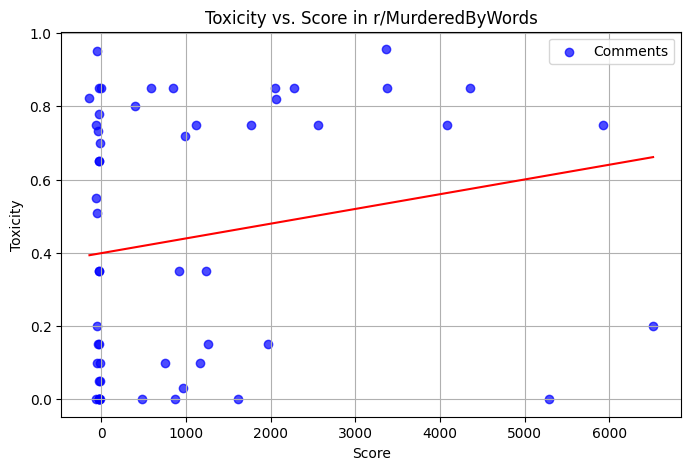

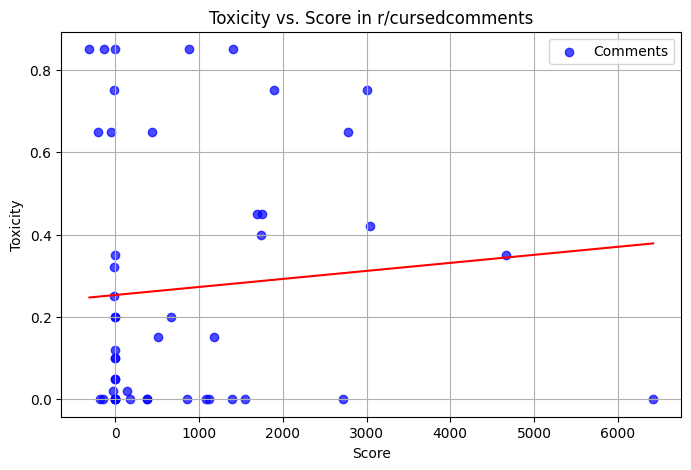

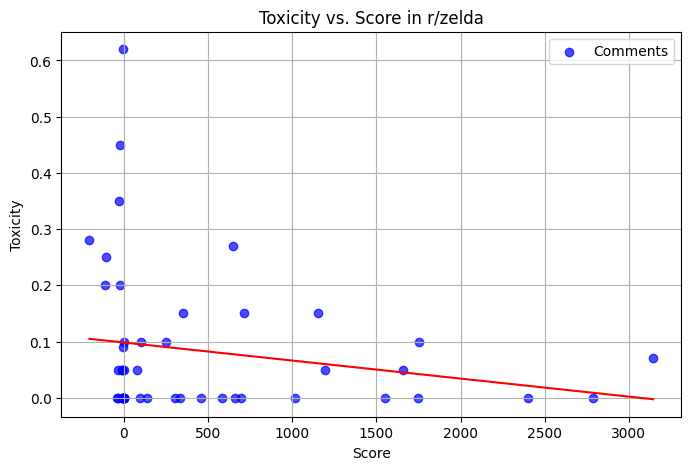

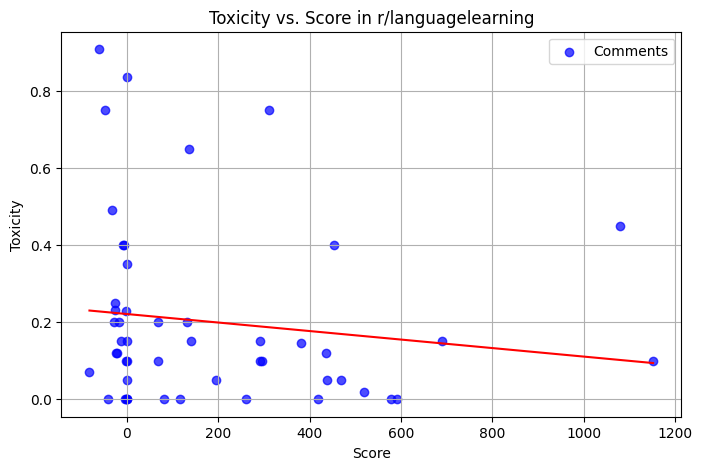

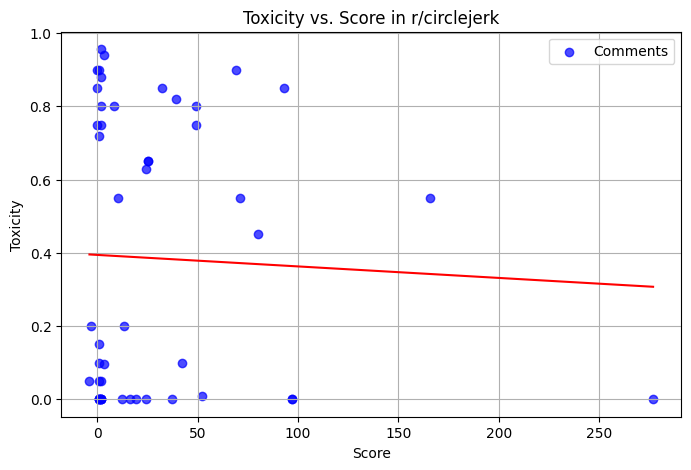

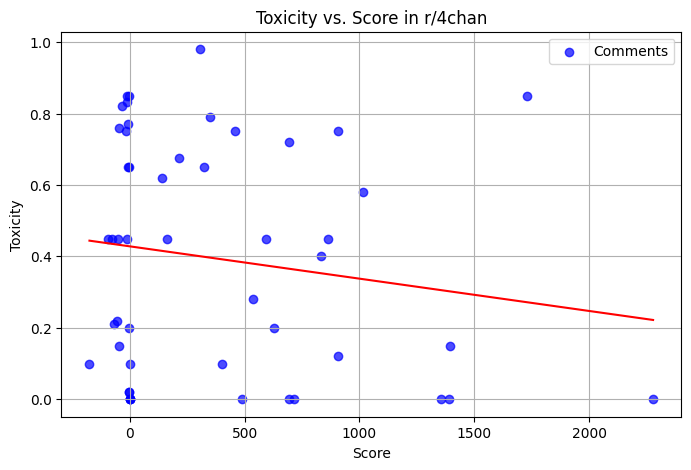

In [138]:
# loop through each subreddit
for subreddit_name, posts in dict_comments.items():
    toxicity_values = []
    score_values = []

    # loop through posts and comments to collect (toxicity, score)
    for post_comments in posts.values():
        for comment in post_comments:
            toxicity_values.append(comment['OpenAI_toxicity'])
            score_values.append(comment['score'])

    plot_toxicity_scores(toxicity_values, score_values)

In [142]:
# high scoring, high toxicity comments
# probably from toxic subreddits
def high_score_high_tox_comments(min_score, min_toxicity):
    for subreddit in dict_comments:
        for post in dict_comments[subreddit]:
            for comment in dict_comments[subreddit][post]:
                if comment['score'] > min_score and comment['OpenAI_toxicity'] > min_toxicity:
                    print('from', subreddit)
                    print('toxicity', comment['OpenAI_toxicity'])
                    print('score', comment['score'])
                    print(comment['body'])
                    print('-'*30)

high_score_high_tox_comments(3000, 0)

from MurderedByWords
toxicity 0.75
score 5921
When trump got covid they used a regimen that included medicine made from stem cells only obtained to from aborted fetuses 
------------------------------
from MurderedByWords
toxicity 0.75
score 4078
Yeah I'm pretty tired of this game they play.  It's like being "pro-life" while stripping benefits from the women you force to become mothers against their will.
------------------------------
from MurderedByWords
toxicity 0.2
score 6516
They blame about 10 Dem governors for all 50 states following Trump's executive order
------------------------------
from MurderedByWords
toxicity 0.85
score 3369
The best part was Trump was first person on the planet to get the jab and then turned around and told his followers not to get it cuz it was a fake virus for propaganda reasons while watching a million people die from it.
------------------------------
from MurderedByWords
toxicity 0.956
score 3364
"Born rich and now the wealthiest piece of human fil

In [146]:
# low scoring comments, high toxicity
def low_score_high_tox_comments(max_score = 0, min_toxicity=0.8):
    for subreddit in dict_comments:
        for post in dict_comments[subreddit]:
            for comment in dict_comments[subreddit][post]:
                if comment['score'] < max_score and comment['OpenAI_toxicity'] > min_toxicity:
                    print('from', subreddit)
                    print('toxicity', comment['OpenAI_toxicity'])
                    print('score', comment['score'])
                    print(comment['body'])
                    print('-'*30)

low_score_high_tox_comments(-100, 0)

from MurderedByWords
toxicity 0.823
score -141
That wasn't advice. It was a question to research things we could use to kill covid within the body.
------------------------------
from cursedcomments
toxicity 0.85
score -136
Racists often think everyone else, like themselves, are secretly racist but just so oppressed by the PC society that they cant be themselves.

So then they unironically say shit like "oh so what it was *one* slip up, *everyone* always has the n word 
------------------------------
from cursedcomments
toxicity 0.65
score -207
I was going to mention something about you just blatantly saying it like that, but then I saw where your from and it makes sense now
------------------------------
from cursedcomments
toxicity 0.85
score -306
people say the n-word when heated? maybe if they're in the habit of saying the n-word a bunch otherwise

edit: lmao what a thing to get downvoted for
------------------------------
from zelda
toxicity 0.25
score -103
Its a boring ass musou 

In [129]:
# low scoring comments, low toxicity
def low_score_low_tox_comments(max_score = 0, min_toxicity=0.2):
    for subreddit in dict_comments:
        for post in dict_comments[subreddit]:
            for comment in dict_comments[subreddit][post]:
                if comment['score'] < max_score and comment['OpenAI_toxicity'] < min_toxicity:
                    print('from', subreddit)
                    print('toxicity', comment['OpenAI_toxicity'])
                    print('score', comment['score'])
                    print(comment['body'])
                    print('-'*30)

low_score_low_tox_comments(0, 0.7)

from MurderedByWords
toxicity 0.0
score -25
How do you know that guy doesn’t think fast food workers should be paid a decent income?
------------------------------
from MurderedByWords
toxicity 0.0
score -27
Fast food isn't quality product
------------------------------
from MurderedByWords
toxicity 0.0
score -28
[removed]
------------------------------
from MurderedByWords
toxicity 0.15
score -24
Tell that to doctors and Nobel prize committee. All these were board certified physicians.
------------------------------
from MurderedByWords
toxicity 0.0
score -27
In 1941, lobotomy was not considered a primitive Barbarian operation that had to be "defended". It was a novel, valid procedure performed by reputed doctors and recognised by medical bodies. As I said, it would go on to win the Nobel Prize in 1949.
------------------------------
from MurderedByWords
toxicity 0.15
score -46
Like giving the best treatment available for the kid? Lobotomy was a nobel prize winning procedure. Rosemary